In [ ]:
!pip -q install shap

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
df = sns.load_dataset("titanic")

df = df[[
    "survived",
    "sex",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]]

df.head()

,survived,sex,pclass,age,sibsp,parch,fare,embarked
0,0,male,3,22.0,1,0,7.2500,S
1,1,female,1,38.0,1,0,71.2833,C
2,1,female,3,26.0,0,0,7.9250,S
3,1,female,1,35.0,1,0,53.1000,S
4,0,male,3,35.0,0,0,8.0500,S


In [ ]:
X = df.drop("survived", axis=1)
y = df["survived"]

categorical = ["sex", "embarked"]
numerical = ["pclass", "age", "sibsp", "parch", "fare"]

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numerical),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical)
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Training completed!")

Training completed!


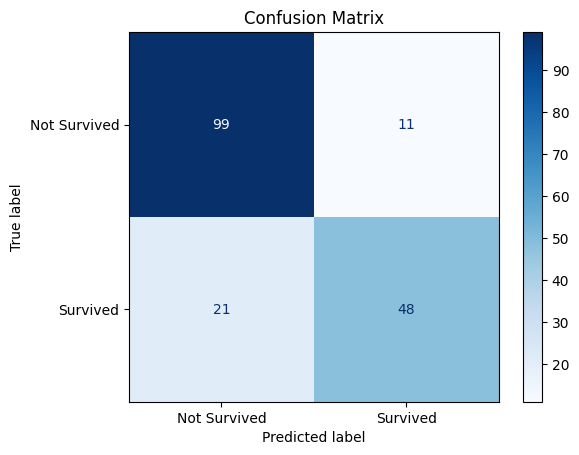

[[99 11]
 [21 48]]


In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Survived", "Survived"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print(cm)

In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Survived", "Survived"]
))

print("Accuracy :", round(accuracy_score(y_test, y_pred),3))
print("Precision:", round(precision_score(y_test, y_pred),3))
print("Recall   :", round(recall_score(y_test, y_pred),3))
print("F1 Score :", round(f1_score(y_test, y_pred),3))

              precision    recall  f1-score   support

Not Survived       0.82      0.90      0.86       110
    Survived       0.81      0.70      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179

Accuracy : 0.821
Precision: 0.814
Recall   : 0.696
F1 Score : 0.75


In [ ]:
eval_df = X_test.copy()

eval_df["actual"] = y_test.values
eval_df["predicted"] = y_pred

eval_df["correct"] = (
    eval_df["actual"] == eval_df["predicted"]
).astype(int)

bias_report = eval_df.groupby("sex")["correct"].mean()

print(bias_report)

sex
female    0.868852
male      0.796610
Name: correct, dtype: float64


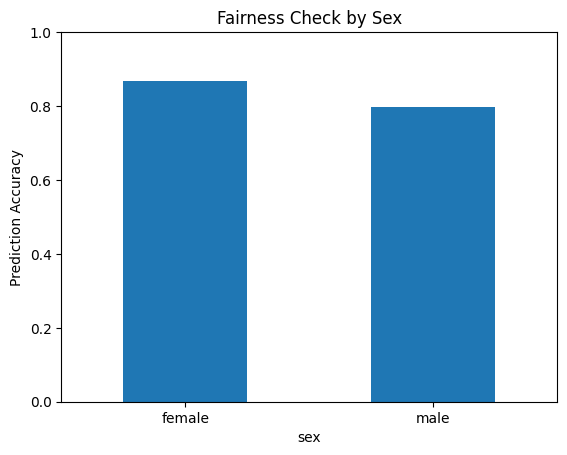

In [ ]:
bias_report.plot(
    kind="bar",
    rot=0
)

plt.ylim(0,1)
plt.ylabel("Prediction Accuracy")
plt.title("Fairness Check by Sex")
plt.show()

In [ ]:
X_train_processed = model.named_steps["preprocessor"].transform(X_train)
X_test_processed = model.named_steps["preprocessor"].transform(X_test)

rf = model.named_steps["classifier"]

feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test_processed)

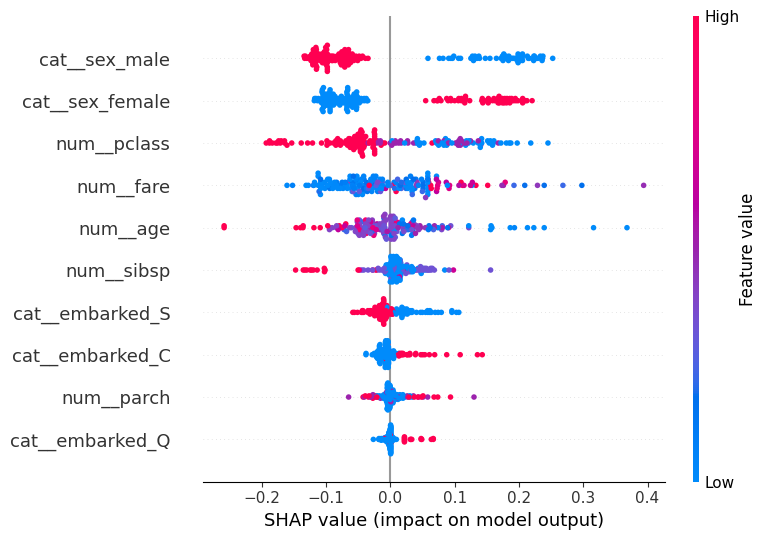

In [ ]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_processed,
    feature_names=feature_names
)

Predicted Class: [0]


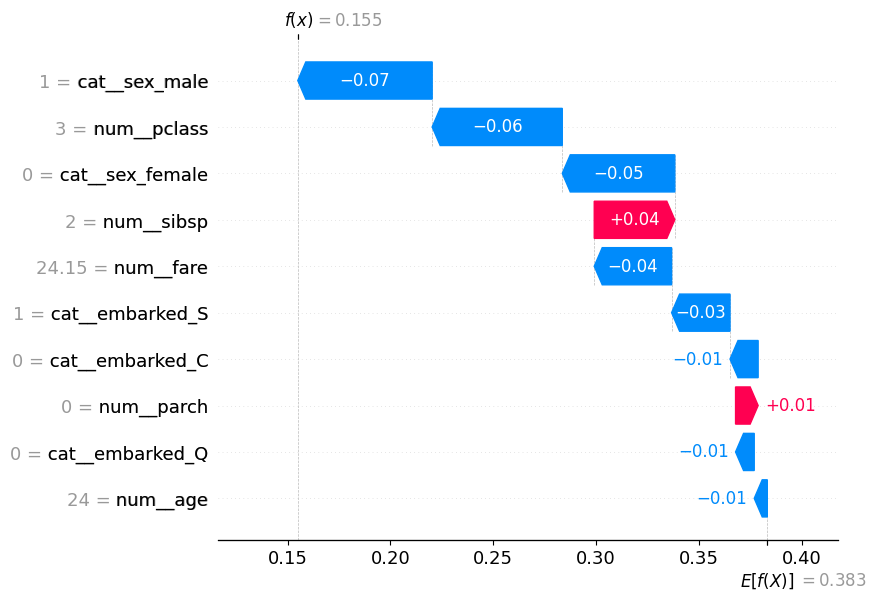

In [ ]:
sample = 0

prediction = rf.predict(
    X_test_processed[sample:sample+1]
)

print("Predicted Class:", prediction)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample,:,1],
        base_values=explainer.expected_value[1],
        data=X_test_processed[sample],
        feature_names=feature_names
    )
)

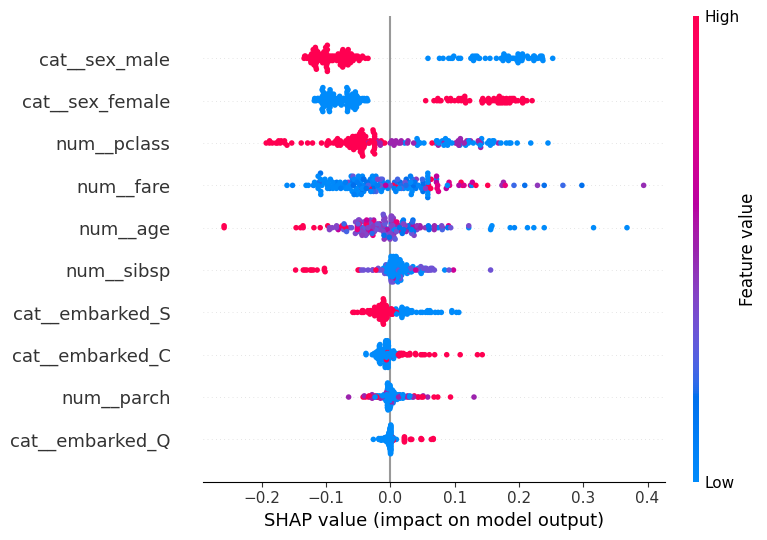

In [ ]:
plt.figure(figsize=(8,6))

shap.summary_plot(
    shap_values[:, :, 1],
    X_test_processed,
    feature_names=feature_names,
    show=False
)

plt.savefig(
    "shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()